# Medical Equipment Suppliers – CRISP-DM Project
**Goal:** Predict whether a provider **accepts assignment** (`acceptsassignement = True/False`)
**CRISP-DM Steps:**
1. Data Understanding
2. Data Preparation
3. Modeling
4. Evaluation
5. Prediction

## Cell 1 – Import Libraries

In [1]:
import micropip
await micropip.install('seaborn')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
%matplotlib inline

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, recall_score,
                             precision_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)


## Cell 2 – Load Data

In [3]:
# Load dataset
df = pd.read_csv('Medical-Equipment-Suppliers.csv')

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())


Shape: (57632, 17)
Columns: ['provider_id', 'acceptsassignement', 'participationbegindate', 'businessname', 'practicename', 'practiceaddress1', 'practiceaddress2', 'practicecity', 'practicestate', 'practicezip9code', 'telephonenumber', 'specialitieslist', 'providertypelist', 'supplieslist', 'latitude', 'longitude', 'is_contracted_for_cba']


## Cell 3 – Explore Data

In [4]:
df.head()

,provider_id,acceptsassignement,participationbegindate,businessname,practicename,practiceaddress1,practiceaddress2,practicecity,practicestate,practicezip9code,telephonenumber,specialitieslist,providertypelist,supplieslist,latitude,longitude,is_contracted_for_cba
0,34362778,False,2025-12-08,LOVING DENTAL LLC,LOVING DENTAL LLC,16838 E PALISADES BLVD,STE 111,FOUNTAIN HILLS,AZ,85268,4808367600,NaN,ORAL SURGERY - DENTIST,Facial Prostheses,33.608389,-111.717044,False
1,34362268,True,2025-12-03,CITI CHEMIST LLC,CITI CHEMIST LLC,3914 104TH ST,NaN,CORONA,NY,113682314,3475322291,Pharmacy,NaN,Epoetin|Immunosuppressive Drugs|Infusion Drugs...,40.750437,-73.862261,False
2,34362670,True,2025-12-01,PRIMEMED PHARMACY LLC,PRIMEMED PHARMACY LLC,486 LINCOLN PL,UNIT 1G,BROOKLYN,NY,112386202,2514087261,Pharmacy,NaN,Epoetin|Immunosuppressive Drugs|Infusion Drugs...,40.671966,-73.960397,False
3,34362514,True,2025-12-01,CG MEDICAL SUPPLIES CORP,CG MEDICAL SUPPLIES CORP,520 N CAMINO MERCADO,SUITE 11,CASA GRANDE,AZ,851225754,8339482409,Medical Supply Company Other,NaN,Automatic Ext Defibrillator (AEDS) and/or Supp...,32.877643,-111.691678,False
4,20564981,True,2025-11-26,SOUTHERN ORTHOCARE INC,SOUTHERN ORTHOCARE INC,740 TELL ST,STE 500,ATHENS,TN,373035171,4232520149,Prosthetic Personnel,NaN,Orthoses: Custom Fabricated|Orthoses: Prefabri...,35.442470,-84.606160,False


In [5]:
df.describe()

,provider_id,practicezip9code,telephonenumber,latitude,longitude
count,5.763200e+04,5.763200e+04,5.763200e+04,57632.000000,57632.000000
mean,2.130771e+07,4.640576e+08,1.478719e+12,37.507681,-89.971780
std,3.076017e+06,2.950657e+08,9.396441e+13,5.319558,15.392592
min,2.030322e+07,6.030000e+02,1.789888e+09,13.393044,-159.584854
25%,2.040031e+07,2.150232e+08,4.024772e+09,33.860273,-96.702897
50%,2.050051e+07,4.331155e+08,6.158649e+09,38.695312,-85.876622
75%,2.061524e+07,7.407530e+08,8.059846e+09,41.159963,-79.058520
max,3.436317e+07,9.992107e+08,9.047333e+15,64.858610,145.702290


In [6]:
print('Missing values:')
print(df.isnull().sum())


Missing values:
provider_id                   0
acceptsassignement            0
participationbegindate        0
businessname                  0
practicename                  0
practiceaddress1              0
practiceaddress2          44717
practicecity                  0
practicestate                 0
practicezip9code              0
telephonenumber               0
specialitieslist            777
providertypelist          50796
supplieslist                 39
latitude                      0
longitude                     0
is_contracted_for_cba         0
dtype: int64


In [7]:
print('Target value counts:')
print(df['acceptsassignement'].value_counts())


Target value counts:
acceptsassignement
True     29623
False    28009
Name: count, dtype: int64


## Cell 4 – EDA Plots

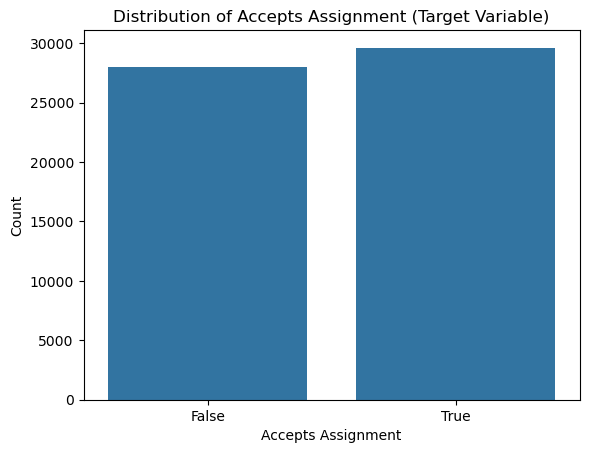

In [8]:
base_color = sb.color_palette()[0]

# Plot 1: Target variable
sb.countplot(data=df, x='acceptsassignement', color=base_color)
plt.title('Distribution of Accepts Assignment (Target Variable)')
plt.xlabel('Accepts Assignment')
plt.ylabel('Count')
plt.show()


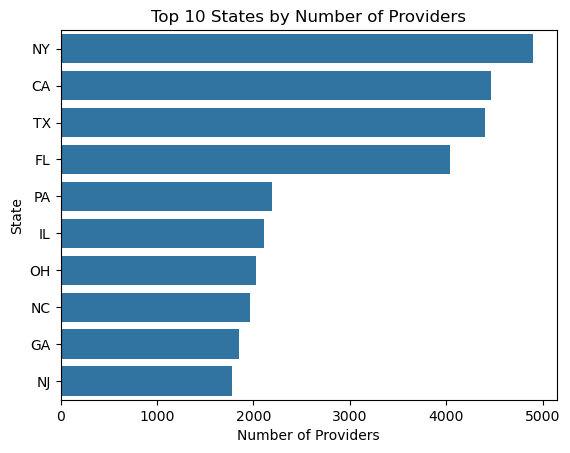

In [9]:
# Plot 2: Top 10 states
top_states = df['practicestate'].value_counts().head(10)
sb.barplot(x=top_states.values, y=top_states.index, color=base_color)
plt.title('Top 10 States by Number of Providers')
plt.xlabel('Number of Providers')
plt.ylabel('State')
plt.show()


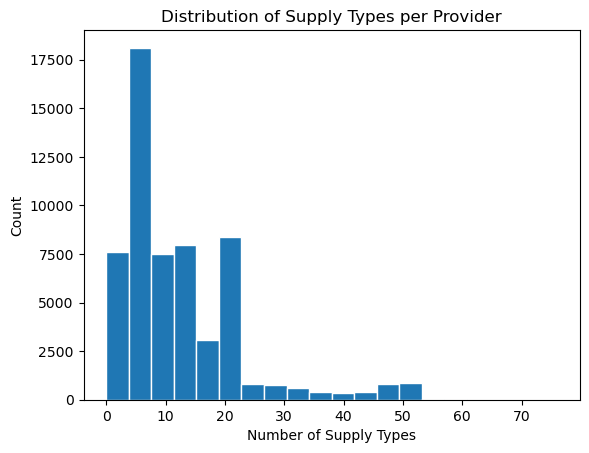

In [10]:
# Plot 3: Supply count distribution
supply_count_temp = df['supplieslist'].fillna('').apply(
    lambda x: len(x.split('|')) if x else 0
)
plt.hist(supply_count_temp, bins=20, color=base_color, edgecolor='white')
plt.title('Distribution of Supply Types per Provider')
plt.xlabel('Number of Supply Types')
plt.ylabel('Count')
plt.show()


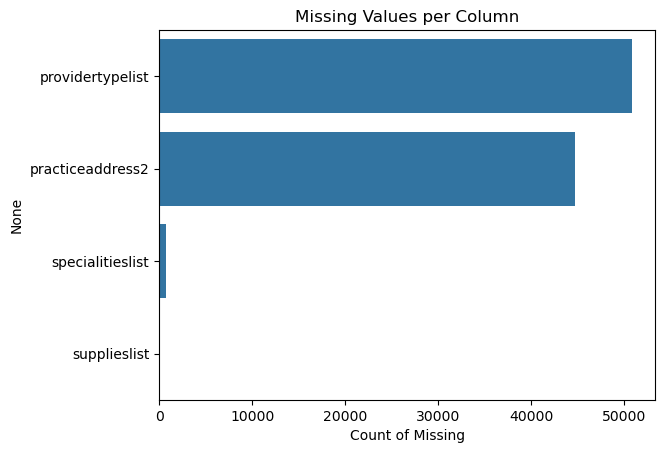

In [11]:
# Plot 4: Missing values bar chart
miss = df.isnull().sum().sort_values(ascending=False)
miss = miss[miss > 0]
sb.barplot(x=miss.values, y=miss.index, color=base_color)
plt.title('Missing Values per Column')
plt.xlabel('Count of Missing')
plt.show()


## Cell 5 – Clean & Prepare Data (All in One Cell)
We do everything to `df` here in one place so there is no confusion about order.


In [14]:
df = pd.read_csv('Medical-Equipment-Suppliers.csv')

# Step A: Drop columns not useful for modeling
df = df.drop(columns=['provider_id',       'businessname',
                       'practicename',      'practiceaddress1',
                       'practiceaddress2',  'telephonenumber',
                       'practicezip9code',  'practicecity',
                       'specialitieslist',  'providertypelist']) 

# Step B: Fill missing values
df['supplieslist'] = df['supplieslist'].fillna('')

# Step C: Create supply_count then drop the text column
df['supply_count'] = df['supplieslist'].apply(
    lambda x: len(x.split('|')) if x else 0)
df = df.drop(columns=['supplieslist'])

# Step D: Extract year from date then drop date column
df['participationbegindate'] = pd.to_datetime(df['participationbegindate'])
df['participation_year']     = df['participationbegindate'].dt.year
df = df.drop(columns=['participationbegindate'])

# Step E: Encode boolean column as 0/1 then drop original
df['cba_encoded'] = df['is_contracted_for_cba'].astype(int)
df = df.drop(columns=['is_contracted_for_cba'])

# Step F: get_dummies 
df = pd.get_dummies(df, columns=['practicestate'])

print('Final df shape:', df.shape)
print('Columns:', df.columns.tolist())

Final df shape: (57632, 61)
Columns: ['acceptsassignement', 'latitude', 'longitude', 'supply_count', 'participation_year', 'cba_encoded', 'practicestate_AK', 'practicestate_AL', 'practicestate_AR', 'practicestate_AZ', 'practicestate_CA', 'practicestate_CO', 'practicestate_CT', 'practicestate_DC', 'practicestate_DE', 'practicestate_FL', 'practicestate_GA', 'practicestate_GU', 'practicestate_HI', 'practicestate_IA', 'practicestate_ID', 'practicestate_IL', 'practicestate_IN', 'practicestate_KS', 'practicestate_KY', 'practicestate_LA', 'practicestate_MA', 'practicestate_MD', 'practicestate_ME', 'practicestate_MI', 'practicestate_MN', 'practicestate_MO', 'practicestate_MP', 'practicestate_MS', 'practicestate_MT', 'practicestate_NC', 'practicestate_ND', 'practicestate_NE', 'practicestate_NH', 'practicestate_NJ', 'practicestate_NM', 'practicestate_NV', 'practicestate_NY', 'practicestate_OH', 'practicestate_OK', 'practicestate_OR', 'practicestate_PA', 'practicestate_PR', 'practicestate_RI', 'p

## Cell 6 – Select Features & Split Data

In [15]:
# Target
y = df['acceptsassignement']

# Features
X = df.drop(columns=['acceptsassignement'])

print('X shape:', X.shape)
print('y shape:', y.shape)
print('y value counts:')
print(y.value_counts())


X shape: (57632, 60)
y shape: (57632,)
y value counts:
acceptsassignement
True     29623
False    28009
Name: count, dtype: int64


In [16]:
# split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)


X_train: (46105, 60)
X_test : (11527, 60)


## Cell 7 – Train Two Models

In [21]:
# Model 1: Logistic Regression (warning: it took time)
lr = LogisticRegression(max_iter=3000, random_state=42, solver='saga', n_jobs=-1)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print('Logistic Regression:-')
print('Accuracy :', round(accuracy_score(y_test,  lr_pred), 4))
print('Recall   :', round(recall_score(y_test,    lr_pred), 4))
print('Precision:', round(precision_score(y_test, lr_pred), 4))
print('F1 Score :', round(f1_score(y_test,        lr_pred), 4))


/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression:-
Accuracy : 0.6932
Recall   : 0.7778
Precision: 0.6733
F1 Score : 0.7218


In [22]:
# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=20, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print('Random Forest:-')
print('Accuracy :', round(accuracy_score(y_test,  rf_pred), 4))
print('Recall   :', round(recall_score(y_test,    rf_pred), 4))
print('Precision:', round(precision_score(y_test, rf_pred), 4))
print('F1 Score :', round(f1_score(y_test,        rf_pred), 4))


Random Forest:-
Accuracy : 0.8739
Recall   : 0.8725
Precision: 0.8801
F1 Score : 0.8763


## Cell 8 – Evaluate Best Model (Random Forest)

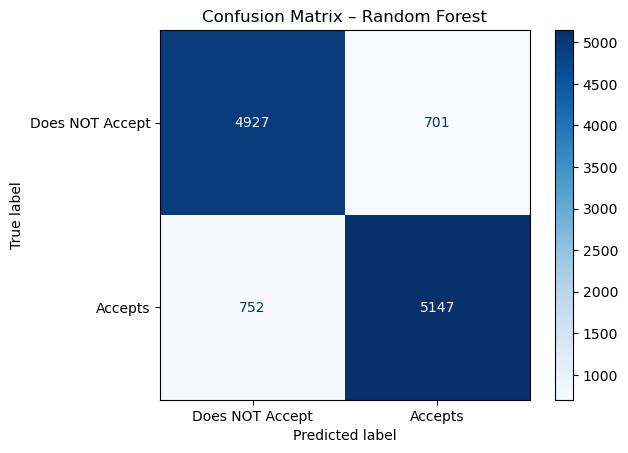

In [23]:
# Confusion Matrix
cm   = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Does NOT Accept', 'Accepts'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix – Random Forest')
plt.show()


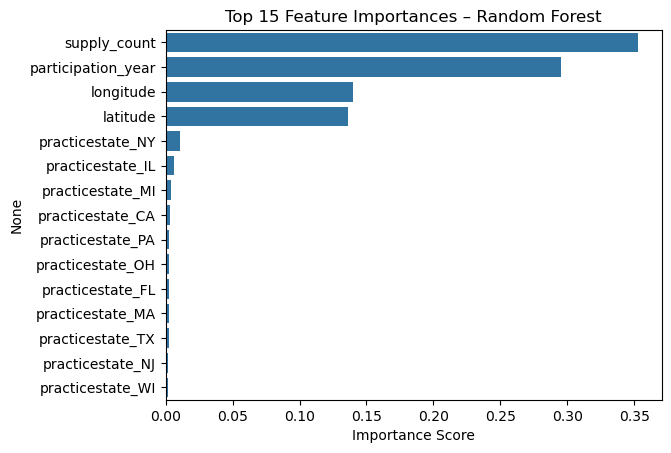

In [24]:
# Top 15 most important features
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(15)

sb.barplot(x=importances.values, y=importances.index, color=base_color)
plt.title('Top 15 Feature Importances – Random Forest')
plt.xlabel('Importance Score')
plt.show()


### Model Comparison

| Metric | Logistic Regression | Random Forest |
|---|---|---|
| **Accuracy** | ~69% | **~87%** |
| **Recall** | ~78% | **~87%** |
| **Precision** | ~67% | **~88%** |
| **F1 Score** | ~0.72 | **~0.88** |


## Cell 9 – Predict a New Scenario
**Scenario:** A new provider in **New York (NY)**, specializing in **Pharmacy**,
offering **8 supply types**, joined in **2023**, not contracted for CBA.


In [25]:
# Start with a row of all zeros matching X columns
new_provider = pd.DataFrame(np.zeros((1, X.shape[1])), columns=X.columns)

# Fill numeric values
new_provider['supply_count']       = 8
new_provider['participation_year'] = 2023
new_provider['cba_encoded']        = 0
new_provider['latitude']           = 40.71
new_provider['longitude']          = -74.00

# Activate the correct columns
for col in ['practicestate_NY', 'specialitieslist_Pharmacy']:
    if col in new_provider.columns:
        new_provider[col] = 1


In [26]:
# Predict
prediction  = rf.predict(new_provider)[0]
probability = rf.predict_proba(new_provider)[0]

print('Prediction        :', 'ACCEPTS Assignment' if prediction else 'Does NOT Accept')
print('Probability False :', round(probability[0], 4))
print('Probability True  :', round(probability[1], 4))


Prediction        : ACCEPTS Assignment
Probability False : 0.1
Probability True  : 0.9
